In [1]:
import pandas as pd

# Apresentando o dataset
df = pd.read_csv('car_price_dataset.csv')
display(df)

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [2]:
# Verificando o tipo de dado de cada atributo
df.dtypes

Brand            object
Model            object
Year              int64
Engine_Size     float64
Fuel_Type        object
Transmission     object
Mileage           int64
Doors             int64
Owner_Count       int64
Price             int64
dtype: object

In [3]:
# Apresentando se contém dados nulos e a quantidade por coluna
df.isnull().sum()

Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [4]:
# Verificando se os nulos são linhas inteiras vazias ou dados dispersos
linhas_completamente_vazias = df.isnull().all(axis=1).sum()
linhas_com_algum_nulo = df.isnull().any(axis=1).sum()

print(f"Linhas com TODOS os valores nulos (completamente vazias): {linhas_completamente_vazias}")
print(f"Linhas com pelo menos UM valor nulo: {linhas_com_algum_nulo}")

if linhas_completamente_vazias == linhas_com_algum_nulo:
    print("\nCONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!")
else:
    print("\nCONCLUSÃO: Existem valores nulos dispersos pelo dataset (alguns dados preenchidos e outros faltando na mesma linha).")

Linhas com TODOS os valores nulos (completamente vazias): 0
Linhas com pelo menos UM valor nulo: 0

CONCLUSÃO: Todos os nulos estão concentrados em linhas inteiras que estão totalmente em branco!


In [5]:
# Removendo as linhas com valores nulos do dataset
df_limpo = df.dropna()

print(f"Número de linhas ANTES da limpeza: {df.shape[0]}")
print(f"Número de linhas DEPOIS da limpeza: {df_limpo.shape[0]}")
print(f"Total de linhas nulas apagadas: {df.shape[0] - df_limpo.shape[0]}\n")

# Verificação final para garantir que não sobrou nenhum nulo
print("Quantidade de nulos após a limpeza:")
print(df_limpo.isnull().sum())

Número de linhas ANTES da limpeza: 10000
Número de linhas DEPOIS da limpeza: 10000
Total de linhas nulas apagadas: 0

Quantidade de nulos após a limpeza:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


In [6]:
# Analisando se os dados numéricos estão normalizados
print("Análise das escalas numéricas ANTES da Normalização:")
colunas_numericas = df_limpo.select_dtypes(include=['int64', 'float64']).columns
colunas_para_normalizar = [col for col in colunas_numericas if col not in ['Price']]

display(df_limpo[colunas_para_normalizar].describe().loc[['min', 'max']])

print("\nCONCLUSÃO: Os dados numéricos NÃO estão normalizados.")

Análise das escalas numéricas ANTES da Normalização:


,Year,Engine_Size,Mileage,Doors,Owner_Count
min,2000.0,1.0,25.0,2.0,1.0
max,2023.0,5.0,299947.0,5.0,5.0



CONCLUSÃO: Os dados numéricos NÃO estão normalizados.


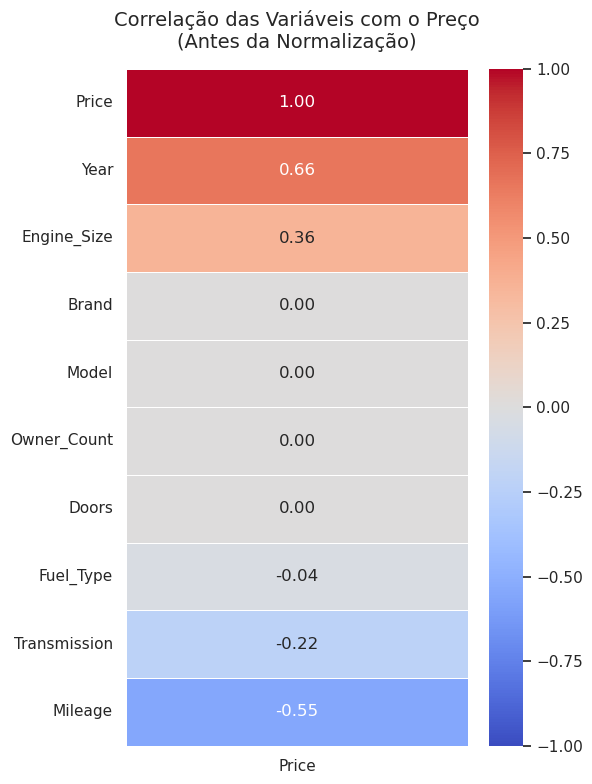

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapa de calor de correlação das variáveis APENAS com o Preço (Antes de Normalizar)
sns.set_theme(style="white")

df_corr = df_limpo.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

correlacoes_preco = df_corr.corr()[['Price']].sort_values(by='Price', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(correlacoes_preco, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Correlação das Variáveis com o Preço\n(Antes da Normalização)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [8]:
# Normalizando as colunas numéricas MANUALMENTE (sem o uso do scikit-learn)
df_normalizado = df_limpo.copy()

for col in colunas_para_normalizar:
    valor_minimo = df_normalizado[col].min()
    valor_maximo = df_normalizado[col].max()
    df_normalizado[col] = (df_normalizado[col] - valor_minimo) / (valor_maximo - valor_minimo)

print("✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!\n")
colunas_verificacao = colunas_para_normalizar + ['Price']
display(df_normalizado[colunas_verificacao].describe().loc[['min', 'max']])

✅ Dados numéricos normalizados com sucesso (O Preço NÃO foi normalizado)!



,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
min,0.0,0.0,0.0,0.0,0.0,2000.0
max,1.0,1.0,1.0,1.0,1.0,18301.0


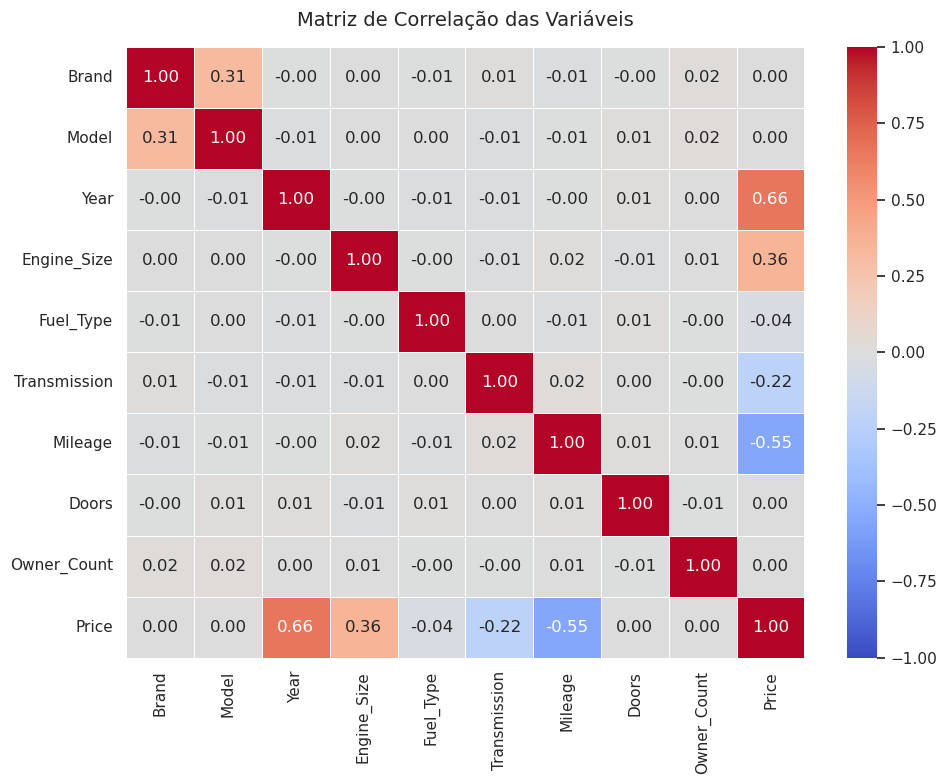

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# MATRIZ DE CORRELAÇÃO DE TODAS AS VARIÁVEIS (Gráfico Quadrado)
sns.set_theme(style="white")

df_matriz = df_limpo.copy()
for col in df_matriz.select_dtypes(include=['object']).columns:
    df_matriz[col] = df_matriz[col].astype('category').cat.codes

matriz_correlacao = df_matriz.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            linewidths=0.5, linecolor='white')
plt.title('Matriz de Correlação das Variáveis', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

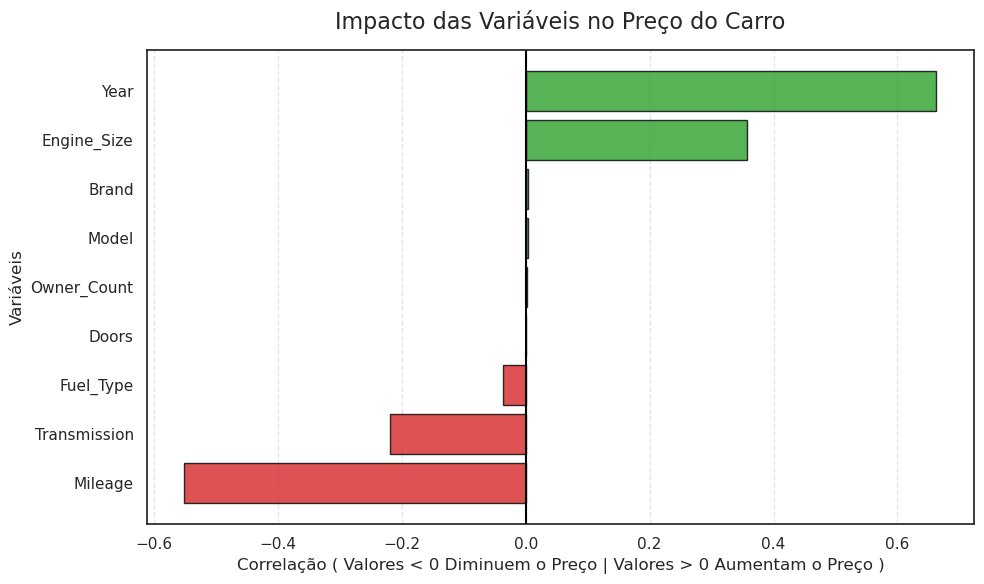

In [10]:
# Gráfico de barras horizontais mostrando o impacto (correlação) de cada variável no Preço
# Variáveis que diminuem o preço ficam à esquerda (vermelho)
# Variáveis que aumentam o preço ficam à direita (verde)

import matplotlib.pyplot as plt

if 'Price' in correlacoes_preco.index:
    corr_plot = correlacoes_preco.drop('Price')
else:
    corr_plot = correlacoes_preco.copy()

corr_plot = corr_plot.sort_values(by='Price')

plt.figure(figsize=(10, 6))
cores = ['#d62728' if x < 0 else '#2ca02c' for x in corr_plot['Price']]

plt.barh(corr_plot.index, corr_plot['Price'], color=cores, edgecolor='black', alpha=0.8)
plt.title('Impacto das Variáveis no Preço do Carro', fontsize=16, pad=15)
plt.xlabel('Correlação ( Valores < 0 Diminuem o Preço | Valores > 0 Aumentam o Preço )', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [11]:
# Removendo as 3 variáveis com correlação irrelevante (praticamente 0)
df_limpo = df_limpo.drop(columns=['Doors', 'Owner_Count', 'Model'])

# Atualizando a variável de correlações para o gráfico não dar erro
correlacoes_preco = correlacoes_preco.drop(index=['Doors', 'Owner_Count', 'Model'], errors='ignore')

print("Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!")


Variáveis 'Doors', 'Owner_Count' e 'Model' foram removidas com sucesso!


In [12]:
# Apresentando o dataset atualizado (agora sem as colunas Doors, Owner_Count e Model)
print("Formato do dataset após a remoção:", df_limpo.shape)
display(df_limpo.head())


Formato do dataset após a remoção: (10000, 7)


,Brand,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Price
0,Kia,2020,4.2,Diesel,Manual,289944,8501
1,Chevrolet,2012,2.0,Hybrid,Automatic,5356,12092
2,Mercedes,2020,4.2,Diesel,Automatic,231440,11171
3,Audi,2023,2.0,Electric,Manual,160971,11780
4,Volkswagen,2003,2.6,Hybrid,Semi-Automatic,286618,2867


Treinamento concluído em 59 épocas!
EQM Final no Treino: 0.003155



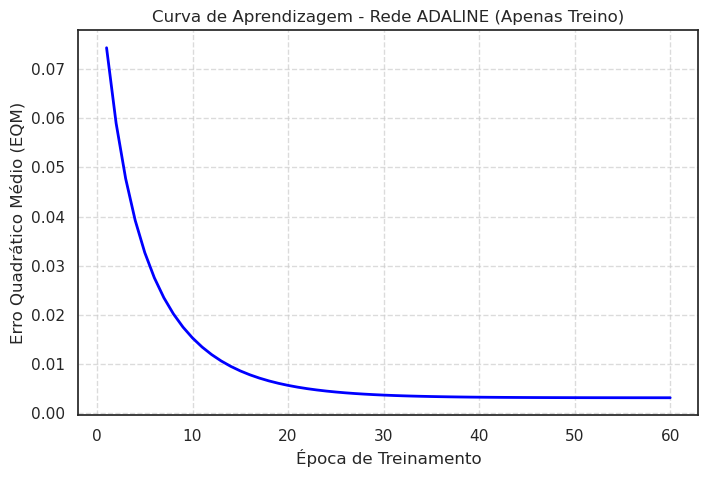

EQM no conjunto de Teste (Normalizado): 0.003238

--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---


,Preço Real,Preço Predito (Adaline),Diferença
0,6012,6656.16,-644.16
1,4008,3577.89,430.11
2,9379,9576.76,-197.76
3,9617,10674.61,-1057.61
4,6843,7593.00,-750.00
5,7438,8539.84,-1101.84
6,13901,14941.00,-1040.00
7,3441,3684.91,-243.91
8,6354,4921.19,1432.81
9,11567,10939.48,627.52


In [13]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO REDE NEURAL ADALINE (REGRA DELTA)
# Parâmetros extraídos do documento Adaline.docx:
# - x0 = -1 (bias)
# - Inicialização de pesos aleatória (0 a 1)
# - Taxa de aprendizado = 0.0025
# - Precisão = 10^-6
# - Conjunto: 800 treino / 200 teste
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação dos dados
# Removendo as variáveis que tinham correlação zero com Price
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

# Transformar variáveis categóricas em numéricas para a rede neural
for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

# Normalização de X (Min-Max) para a rede Adaline convergir
X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

# Normalização do Y (Preço)
y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

# Inserindo o termo de bias x0 = -1 na matriz de entrada X
X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

# Divisão de Treino (800) e Teste (200)
X_treino = X_bias[:800]
y_treino = y_norm[:800]

X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Parâmetros da Rede ADALINE
taxa_aprendizado = 0.0025
precisao = 1e-6
max_epocas = 1500

# Inicializando pesos aleatórios entre 0 e 1
np.random.seed(42)
w = np.random.rand(X_treino.shape[1])

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# 3. Treinamento da Rede ADALINE com Regra Delta (Apenas nos 800 primeiros)
while epoca < max_epocas:
    for i in range(len(X_treino)):
        u = np.dot(w, X_treino[i])
        erro = y_treino[i] - u
        
        # Atualização dos pesos (w = w + taxa * erro * x)
        w = w + taxa_aprendizado * erro * X_treino[i]
    
    # Cálculo do EQM ao final da época
    u_todos = np.dot(X_treino, w)
    erros_amostras = y_treino - u_todos
    eqm_atual = np.mean(erros_amostras**2)
    erros_epocas.append(eqm_atual)
    
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

print(f"Treinamento concluído em {epoca} épocas!")
print(f"EQM Final no Treino: {eqm_atual:.6f}\n")

# 4. Gráfico do EQM em função da Época
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='blue', linewidth=2)
plt.title('Curva de Aprendizagem - Rede ADALINE (Apenas Treino)')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação no conjunto de Teste (200 registros)
predicoes_teste_norm = np.dot(X_teste, w)
predicoes_teste_reais = predicoes_teste_norm * (preco_max - preco_min) + preco_min

# Calculando EQM no Teste
erros_teste_norm = y_teste - predicoes_teste_norm
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

# Mostrando algumas predições do Teste em Reais
resultados_teste = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (Adaline)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no conjunto de TESTE (Linhas 800 a 810) ---")
display(resultados_teste)


Treinamento PMC concluído em 451 épocas!
EQM Final no Treinamento: 0.000622



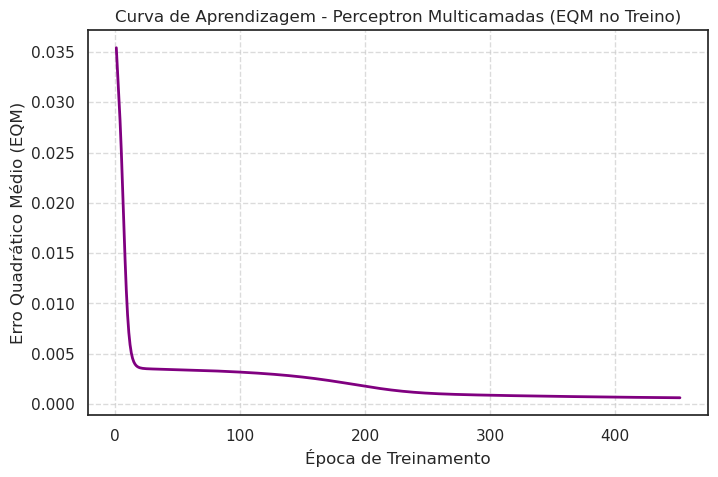

EQM no conjunto de Teste (Normalizado): 0.000618

--- Primeiras 10 predições no conjunto de TESTE (PMC) ---


,Preço Real,Preço Predito (PMC),Diferença
0,6012,5913.86,98.14
1,4008,4264.13,-256.13
2,9379,9928.82,-549.82
3,9617,9457.81,159.19
4,6843,6728.51,114.49
5,7438,7150.27,287.73
6,13901,13492.88,408.12
7,3441,4101.12,-660.12
8,6354,5668.39,685.61
9,11567,12028.68,-461.68


In [14]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC)
# Algoritmo: Backpropagation (Regra Delta Generalizada)
# Parâmetros baseados no arquivo PMC1.docx
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparação e Separação (800 treino / 200 teste)
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

# Transformar categorias em números
for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

# Normalização de X
X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

# Normalização do Y (Preço) entre 0 e 1, pois a Logística (Sigmoide) gera saídas entre 0 e 1
y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

# Bias x0 = -1 inserido na entrada
X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

X_treino = X_bias[:800]
y_treino = y_norm[:800]
X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Arquitetura da Rede e Funções de Ativação
def logistica(x):
    x = np.clip(x, -500, 500) # Evita travamento matemático (overflow)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
precisao = 1e-6
max_epocas = 1500

n_entradas = X_treino.shape[1] # Incluindo bias
n_ocultos = 10                 # 10 neurônios na camada oculta
n_saida = 1

np.random.seed(42)
# Pesos Iniciais: Aleatórios entre 0 e 1
W_oculta = np.random.rand(n_entradas, n_ocultos)

# A camada oculta também emite um bias (-1) para a camada de saída
W_saida = np.random.rand(n_ocultos + 1, n_saida)

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# 3. Treinamento (Algoritmo Backpropagation)
while epoca < max_epocas:
    
    # Processa cada amostra do conjunto de treinamento
    for i in range(len(X_treino)):
        x_in = X_treino[i:i+1] # Padrão atual de entrada (formato de matriz linha)
        y_desejado = y_treino[i]
        
        # --- ETAPA FORWARD ---
        # Camada Oculta
        net_oculta = np.dot(x_in, W_oculta)
        out_oculta = logistica(net_oculta)
        
        # Inserindo o termo de bias (-1) na saída da camada oculta para ir à saída
        out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
        
        # Camada de Saída
        net_saida = np.dot(out_oculta_bias, W_saida)
        out_saida = logistica(net_saida)
        
        # --- ETAPA BACKWARD (Cálculo dos Gradientes e Erros) ---
        erro = y_desejado - out_saida
        
        # Gradiente local da camada de saída
        delta_saida = erro * logistica_derivada(net_saida)
        
        # Gradiente local da camada oculta (desconsidera o peso referente ao bias)
        W_saida_sem_bias = W_saida[1:, :] 
        delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
        
        # --- ATUALIZAÇÃO DOS PESOS (Regra Delta Generalizada) ---
        W_saida = W_saida + taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
        W_oculta = W_oculta + taxa_aprendizado * np.dot(x_in.T, delta_oculta)
    
    # Cálculo do EQM Global da época para checar a Precisão
    net_oculta_all = np.dot(X_treino, W_oculta)
    out_oculta_all = logistica(net_oculta_all)
    out_oculta_bias_all = np.c_[np.full(len(X_treino), -1), out_oculta_all]
    out_saida_all = logistica(np.dot(out_oculta_bias_all, W_saida))
    
    eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
    erros_epocas.append(eqm_atual)
    
    # Critério de Parada
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

print(f"Treinamento PMC concluído em {epoca} épocas!")
print(f"EQM Final no Treinamento: {eqm_atual:.6f}\n")

# 4. Gráfico do EQM em função da Época
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='purple', linewidth=2)
plt.title('Curva de Aprendizagem - Perceptron Multicamadas (EQM no Treino)')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação do Modelo no Conjunto de TESTE
net_oculta_teste = np.dot(X_teste, W_oculta)
out_oculta_teste = logistica(net_oculta_teste)
out_oculta_bias_teste = np.c_[np.full(len(X_teste), -1), out_oculta_teste]
out_saida_teste = logistica(np.dot(out_oculta_bias_teste, W_saida))

# Desnormalizando as predições para obtermos o valor financeiro do Carro
predicoes_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min

# EQM Normalizado do Teste
erros_teste_norm = y_teste - out_saida_teste.flatten()
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

# Visualização Real - Primeiros 10 testes
resultados_teste_pmc = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (PMC)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no conjunto de TESTE (PMC) ---")
display(resultados_teste_pmc)


Treinamento PMC COM MOMENTUM concluído em 128 épocas!
Tempo de Processamento: 8.61 segundos
EQM Final no Treinamento: 0.000317



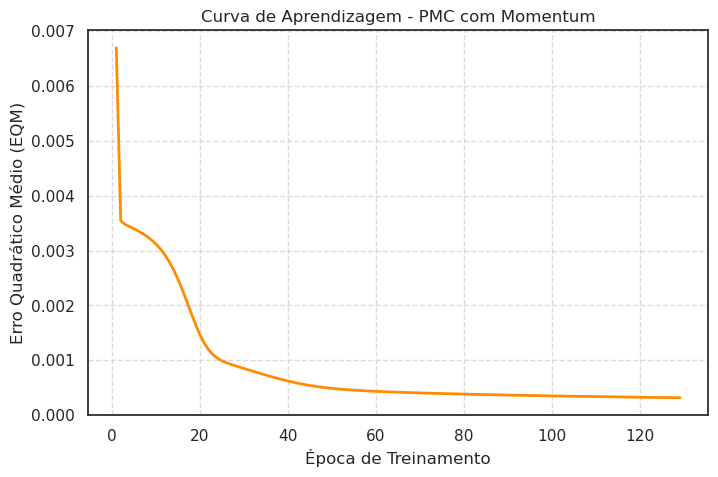

EQM no conjunto de Teste (Normalizado): 0.000302

--- Primeiras 10 predições no TESTE (PMC com Momentum) ---


,Preço Real,Preço Predito (PMC Momentum),Diferença
0,6012,5733.49,278.51
1,4008,4349.99,-341.99
2,9379,9614.55,-235.55
3,9617,9534.16,82.84
4,6843,6725.02,117.98
5,7438,7204.99,233.01
6,13901,13527.05,373.95
7,3441,4046.63,-605.63
8,6354,5867.89,486.11
9,11567,11965.58,-398.58


In [15]:
# ==================================================================
# PREDIÇÃO DE PREÇO UTILIZANDO PERCEPTRON MULTICAMADAS (PMC) COM MOMENTUM
# Algoritmo: Backpropagation com Momentum
# Parâmetros baseados no arquivo PMC2.docx
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# 1. Preparação (800 treino / 200 teste)
features = [c for c in df_limpo.columns if c not in ['Price', 'Doors', 'Owner_Count', 'Model']]
X_df = df_limpo[features].copy()

for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes

X_norm = (X_df - X_df.min()) / (X_df.max() - X_df.min())
X_arr = X_norm.values

y_arr = df_limpo['Price'].values
preco_min = y_arr.min()
preco_max = y_arr.max()
y_norm = (y_arr - preco_min) / (preco_max - preco_min)

X_bias = np.c_[np.full(X_arr.shape[0], -1), X_arr]

X_treino = X_bias[:800]
y_treino = y_norm[:800]
X_teste = X_bias[800:1000]
y_teste = y_norm[800:1000]
y_teste_reais = y_arr[800:1000]

# 2. Arquitetura e Funções
def logistica(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
fator_momentum = 0.9
precisao = 1e-6
max_epocas = 1500

n_entradas = X_treino.shape[1] 
n_ocultos = 15                 # 15 neurônios na oculta (baseado no PMC2)
n_saida = 1

np.random.seed(42)
W_oculta = np.random.rand(n_entradas, n_ocultos)
W_saida = np.random.rand(n_ocultos + 1, n_saida)

# Matrizes para guardar o Delta dos pesos da época anterior (Necessário para o Momentum)
delta_W_oculta_ant = np.zeros_like(W_oculta)
delta_W_saida_ant = np.zeros_like(W_saida)

erros_epocas = []
epoca = 0
eqm_anterior = float('inf')

# Marcando o tempo de início
start_time = time.time()

# 3. Treinamento (Backpropagation COM MOMENTUM)
while epoca < max_epocas:
    for i in range(len(X_treino)):
        x_in = X_treino[i:i+1]
        y_desejado = y_treino[i]
        
        # --- FORWARD ---
        net_oculta = np.dot(x_in, W_oculta)
        out_oculta = logistica(net_oculta)
        
        out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
        
        net_saida = np.dot(out_oculta_bias, W_saida)
        out_saida = logistica(net_saida)
        
        # --- BACKWARD ---
        erro = y_desejado - out_saida
        delta_saida = erro * logistica_derivada(net_saida)
        
        W_saida_sem_bias = W_saida[1:, :] 
        delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
        
        # --- ATUALIZAÇÃO COM MOMENTUM ---
        # Formula: Peso = Peso + (Taxa * Gradiente) + (Alfa * DeltaAnterior)
        
        grad_saida = taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
        atualizacao_W_saida = grad_saida + (fator_momentum * delta_W_saida_ant)
        W_saida = W_saida + atualizacao_W_saida
        delta_W_saida_ant = atualizacao_W_saida
        
        grad_oculta = taxa_aprendizado * np.dot(x_in.T, delta_oculta)
        atualizacao_W_oculta = grad_oculta + (fator_momentum * delta_W_oculta_ant)
        W_oculta = W_oculta + atualizacao_W_oculta
        delta_W_oculta_ant = atualizacao_W_oculta
    
    # EQM Global
    net_oculta_all = np.dot(X_treino, W_oculta)
    out_oculta_all = logistica(net_oculta_all)
    out_oculta_bias_all = np.c_[np.full(len(X_treino), -1), out_oculta_all]
    out_saida_all = logistica(np.dot(out_oculta_bias_all, W_saida))
    
    eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
    erros_epocas.append(eqm_atual)
    
    if abs(eqm_anterior - eqm_atual) < precisao:
        break
        
    eqm_anterior = eqm_atual
    epoca += 1

tempo_treino = time.time() - start_time

print(f"Treinamento PMC COM MOMENTUM concluído em {epoca} épocas!")
print(f"Tempo de Processamento: {tempo_treino:.2f} segundos")
print(f"EQM Final no Treinamento: {eqm_atual:.6f}\n")

# 4. Gráfico da Curva de Aprendizagem
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color='darkorange', linewidth=2)
plt.title('Curva de Aprendizagem - PMC com Momentum')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (EQM)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5. Avaliação no TESTE
net_oculta_teste = np.dot(X_teste, W_oculta)
out_oculta_teste = logistica(net_oculta_teste)
out_oculta_bias_teste = np.c_[np.full(len(X_teste), -1), out_oculta_teste]
out_saida_teste = logistica(np.dot(out_oculta_bias_teste, W_saida))

predicoes_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min

erros_teste_norm = y_teste - out_saida_teste.flatten()
eqm_teste = np.mean(erros_teste_norm**2)
print(f"EQM no conjunto de Teste (Normalizado): {eqm_teste:.6f}\n")

resultados_teste_pmc2 = pd.DataFrame({
    'Preço Real': y_teste_reais[:10],
    'Preço Predito (PMC Momentum)': predicoes_teste_reais[:10].round(2),
    'Diferença': (y_teste_reais[:10] - predicoes_teste_reais[:10]).round(2)
})

print("--- Primeiras 10 predições no TESTE (PMC com Momentum) ---")
display(resultados_teste_pmc2)



--- Treinando Rede 1 (Atrasos p=5, Ocultos=5) ---
Treino concluído: 113 épocas | EQM Final: 0.034568


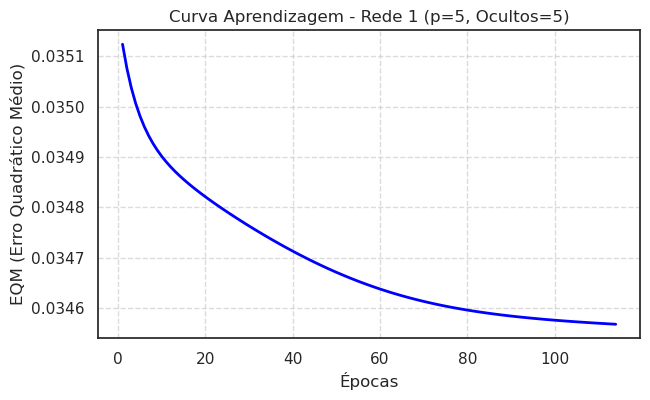

TESTE - Erro Relativo Médio: 35.5835%
TESTE - Variância do Erro: 2702.6882


--- Treinando Rede 2 (Atrasos p=5, Ocultos=10) ---
Treino concluído: 1500 épocas | EQM Final: 0.033091


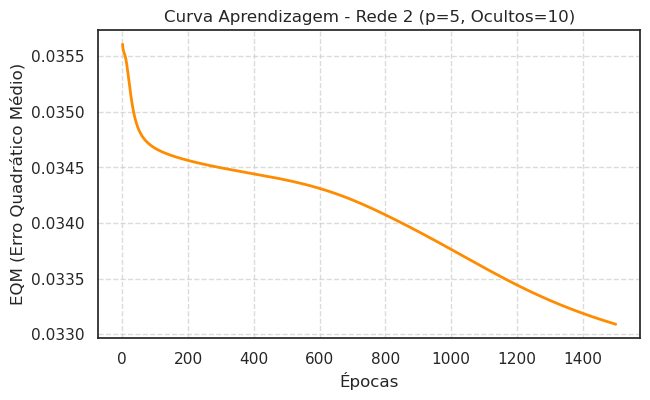

TESTE - Erro Relativo Médio: 36.9909%
TESTE - Variância do Erro: 2775.5205


--- Treinando Rede 3 (Atrasos p=5, Ocultos=20) ---
Treino concluído: 311 épocas | EQM Final: 0.034537


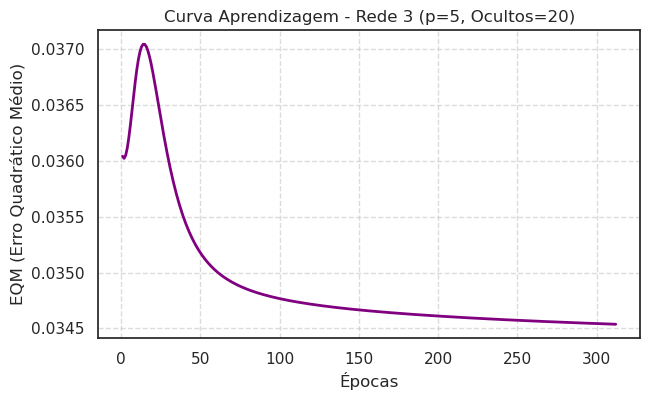

TESTE - Erro Relativo Médio: 35.6623%
TESTE - Variância do Erro: 2722.4416



In [21]:
# ==================================================================
# TDNN (TIME DELAY) - TREINAMENTO AUTOMÁTICO DAS 3 REDES
# Baseado no PMC3.docx:
# Rede 1: p=5 atrasos, 5 Neurônios Ocultos
# Rede 2: p=10 atrasos, 10 Neurônios Ocultos
# Rede 3: p=15 atrasos, 20 Neurônios Ocultos
# ==================================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

serie_preco = df_limpo['Price'].values
preco_min, preco_max = serie_preco.min(), serie_preco.max()
serie_norm = (serie_preco - preco_min) / (preco_max - preco_min)

def criar_janelas(serie, p):
    X, Y = [], []
    for i in range(len(serie) - p):
        X.append(serie[i : i + p])
        Y.append(serie[i + p])
    return np.array(X), np.array(Y)

def logistica(x):
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def logistica_derivada(x):
    sig = logistica(x)
    return sig * (1 - sig)

taxa_aprendizado = 0.1
fator_momentum = 0.8
precisao = 0.5e-6
max_epocas = 1500

# DEFINIÇÃO DAS 3 REDES PEDIDAS
configuracoes = [
    {'nome': 'Rede 1', 'p': 5, 'n_ocultos': 5, 'cor': 'blue'},
    {'nome': 'Rede 2', 'p': 5, 'n_ocultos': 10, 'cor': 'darkorange'},
    {'nome': 'Rede 3', 'p': 5, 'n_ocultos': 20, 'cor': 'purple'}
]

for config in configuracoes:
    print(f"\n=======================================================")
    print(f"--- Treinando {config['nome']} (Atrasos p={config['p']}, Ocultos={config['n_ocultos']}) ---")
    p = config['p']
    n_ocultos = config['n_ocultos']
    
    X_tdnn, y_tdnn = criar_janelas(serie_norm, p)
    X_bias = np.c_[np.full(X_tdnn.shape[0], -1), X_tdnn]

    # Mantendo sempre 800 pra treino e 200 pra teste
    X_treino, y_treino = X_bias[:500], y_tdnn[:500]
    X_teste, y_teste = X_bias[500:700], y_tdnn[500:700]
    
    n_entradas = X_treino.shape[1] 
    n_saida = 1

    np.random.seed(42)
    W_oculta = np.random.rand(n_entradas, n_ocultos)
    W_saida = np.random.rand(n_ocultos + 1, n_saida)

    delta_W_oculta_ant = np.zeros_like(W_oculta)
    delta_W_saida_ant = np.zeros_like(W_saida)

    erros_epocas, epoca, eqm_anterior = [], 0, float('inf')

    # Treinamento da Rede Específica
    while epoca < max_epocas:
        for i in range(len(X_treino)):
            x_in, y_desejado = X_treino[i:i+1], y_treino[i]
            
            # Forward
            net_oculta = np.dot(x_in, W_oculta)
            out_oculta = logistica(net_oculta)
            out_oculta_bias = np.c_[np.array([[-1]]), out_oculta]
            
            net_saida = np.dot(out_oculta_bias, W_saida)
            out_saida = logistica(net_saida)
            
            # Backward
            erro = y_desejado - out_saida
            delta_saida = erro * logistica_derivada(net_saida)
            W_saida_sem_bias = W_saida[1:, :] 
            delta_oculta = np.dot(delta_saida, W_saida_sem_bias.T) * logistica_derivada(net_oculta)
            
            # Momentum
            grad_saida = taxa_aprendizado * np.dot(out_oculta_bias.T, delta_saida)
            atualizacao_W_saida = grad_saida + (fator_momentum * delta_W_saida_ant)
            W_saida += atualizacao_W_saida
            delta_W_saida_ant = atualizacao_W_saida
            
            grad_oculta = taxa_aprendizado * np.dot(x_in.T, delta_oculta)
            atualizacao_W_oculta = grad_oculta + (fator_momentum * delta_W_oculta_ant)
            W_oculta += atualizacao_W_oculta
            delta_W_oculta_ant = atualizacao_W_oculta
        
        # EQM Global
        net_oculta_all = logistica(np.dot(X_treino, W_oculta))
        out_saida_all = logistica(np.dot(np.c_[np.full(len(X_treino), -1), net_oculta_all], W_saida))
        
        eqm_atual = np.mean((y_treino.reshape(-1, 1) - out_saida_all)**2)
        erros_epocas.append(eqm_atual)
        
        if abs(eqm_anterior - eqm_atual) < precisao:
            break
        eqm_anterior = eqm_atual
        epoca += 1

    print(f"Treino concluído: {epoca} épocas | EQM Final: {eqm_atual:.6f}")

    # Gráfico
    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(erros_epocas) + 1), erros_epocas, color=config['cor'], linewidth=2)
    plt.title(f"Curva Aprendizagem - {config['nome']} (p={p}, Ocultos={n_ocultos})")
    plt.xlabel('Épocas')
    plt.ylabel('EQM (Erro Quadrático Médio)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Validação no Teste
    net_oculta_teste = logistica(np.dot(X_teste, W_oculta))
    out_saida_teste = logistica(np.dot(np.c_[np.full(len(X_teste), -1), net_oculta_teste], W_saida))

    pred_teste_reais = out_saida_teste.flatten() * (preco_max - preco_min) + preco_min
    y_teste_reais = y_teste * (preco_max - preco_min) + preco_min

    erros_relativos = abs(y_teste_reais - pred_teste_reais) / y_teste_reais * 100
    
    print(f"TESTE - Erro Relativo Médio: {np.mean(erros_relativos):.4f}%")
    print(f"TESTE - Variância do Erro: {np.var(erros_relativos):.4f}\n")
